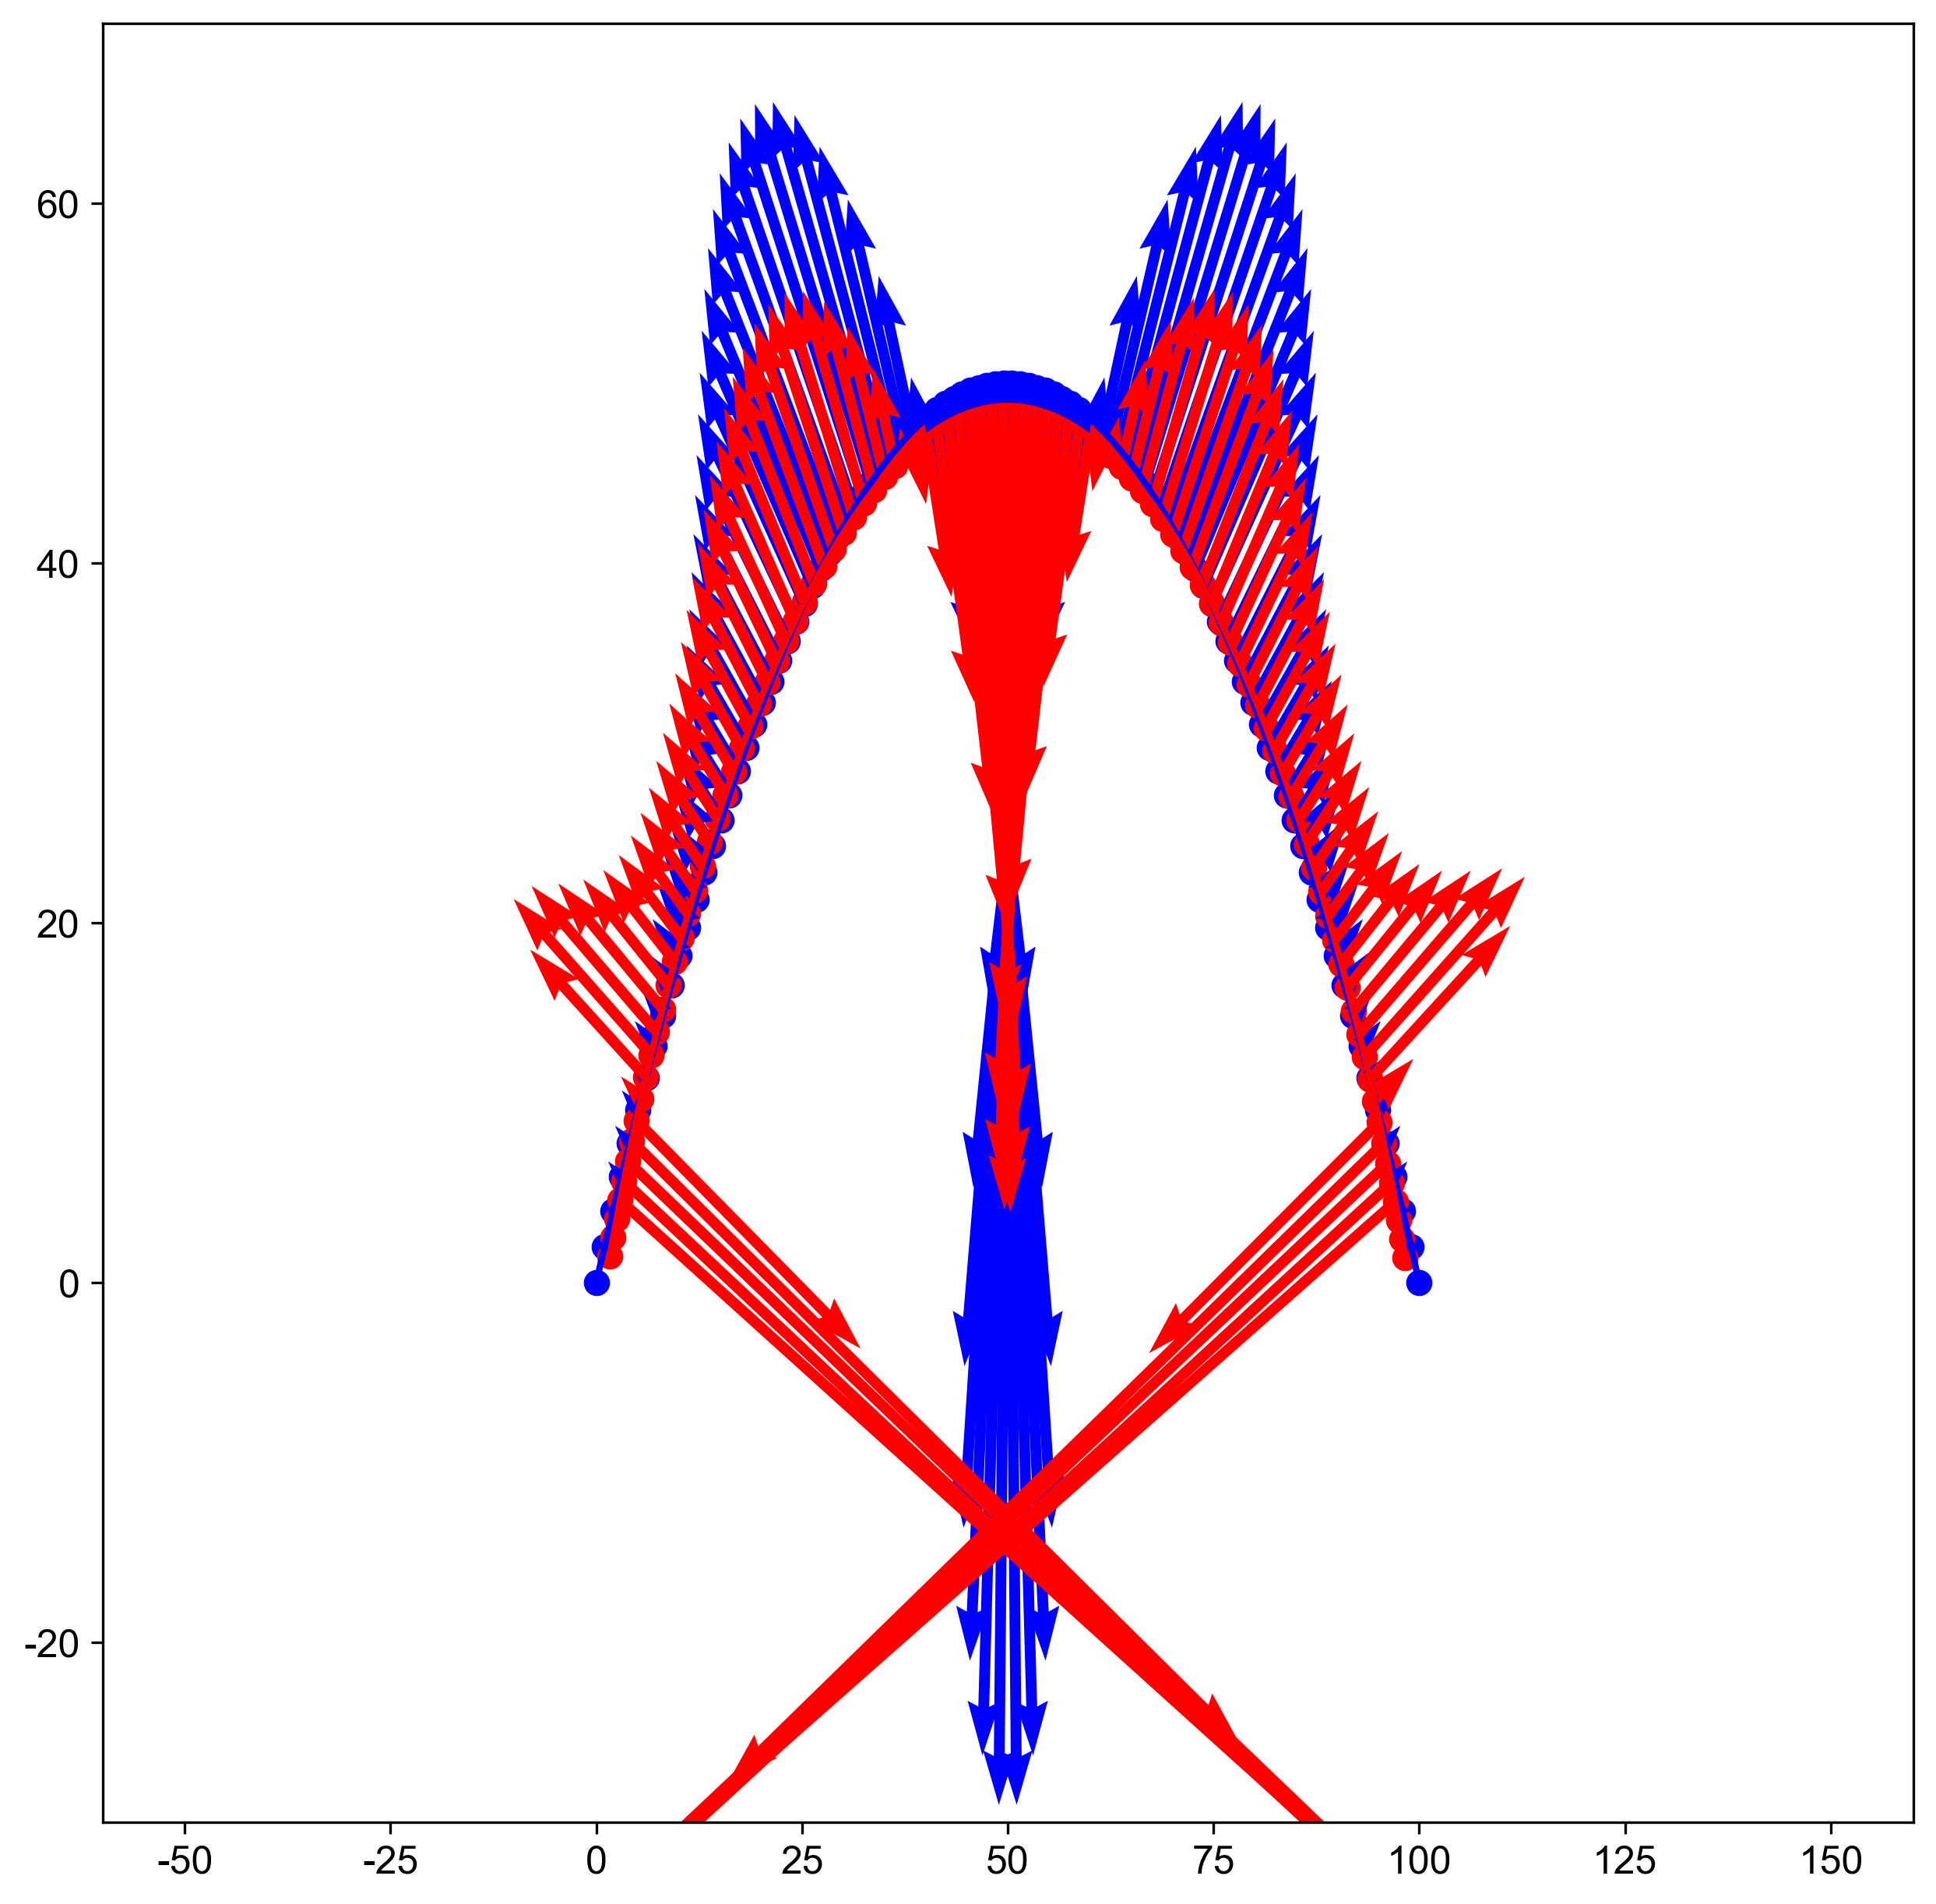

In [18]:
import os
import matplotlib.pyplot as plt
import numpy as np
from variation_run import get_force_density
from sample import make_parabola

def compare_bend(
		coords_1: np.ndarray, 
		coords_2: np.ndarray,
		forces_1: np.ndarray, 
		forces_2: np.ndarray,
		scale, ax):
    
    scale_factor = 1e5

    x_coords_1 = coords_1[:, 0]
    y_coords_1 = coords_1[:, 1]

    x_coords_2 = coords_2[:, 0]
    y_coords_2 = coords_2[:, 1]
    
    fx_1 = forces_1[:, 0] * scale_factor
    fy_1 = forces_1[:, 1] * scale_factor

    fx_2 = forces_2[:, 0] * scale_factor
    fy_2 = forces_2[:, 1] * scale_factor
    
    # Use the passed axis to plot
    ax.scatter(x_coords_1, y_coords_1, color='blue', label='Nodes', s=50)
    ax.scatter(x_coords_2, y_coords_2, color='red', label='Nodes', s=50)
    
    ax.plot(x_coords_1, y_coords_1, color='blue', linestyle='-', linewidth=2)
    ax.plot(x_coords_2, y_coords_2, color='red', linestyle='-', linewidth=2)

    ax.quiver(x_coords_1, y_coords_1, fx_1, fy_1, color='blue', angles='xy', scale_units='xy', scale=scale)
    ax.quiver(x_coords_2, y_coords_2, fx_2, fy_2, color='red', angles='xy', scale_units='xy', scale=scale)
    
    # ax.legend()
    ax.set_xlim(-60, 160)
    ax.set_ylim(-30, 70)


parameters = {
    "Kb":  100 / 4,   # Bending modulus (pN nm)
    "Ksg": 0.5,    # Global stretching modulus (pN nm)
    "Ksl": 0,
    "boundary": "fixed"
}

N_node = 100
L_etoe = 100
height = 50
noise_level = 0.1
n_vertices = 100
k_val = 4
s_val = 100


coords_1 = make_parabola(N_node = N_node, L_etoe = L_etoe, height = height, point_dist = "unif")
forces_1 = get_force_density(parameters, coords_1)

file_path = os.path.join(f"dat/spline_test", f"n{N_node}_{noise_level:.2f}".replace('.', '') + f"_n{n_vertices:03d}_s{s_val:03d}_k{k_val}.npz")
data = np.load(file_path)
coords_2 = data['coords']
forces_2 = get_force_density(parameters, coords_2)

fig, axes = plt.subplots(1, 1, figsize=(10, 10))
compare_bend(coords_1, coords_2, forces_1[0], forces_2[0], scale=10, ax=axes)

plt.savefig(f"figures/compare/force_n{N_node}_{noise_level:.2f}".replace('.', '')+ f"_n{n_vertices:03d}_s{s_val}k{k_val}.png", dpi=300)
plt.show()

